In [12]:
import pandas as pd
df=pd.read_csv('Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [13]:
print(df['Channel'].value_counts())
df['Region'].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64


Region
3    316
1     77
2     47
Name: count, dtype: int64

In [14]:
x=df.iloc[:,2:]

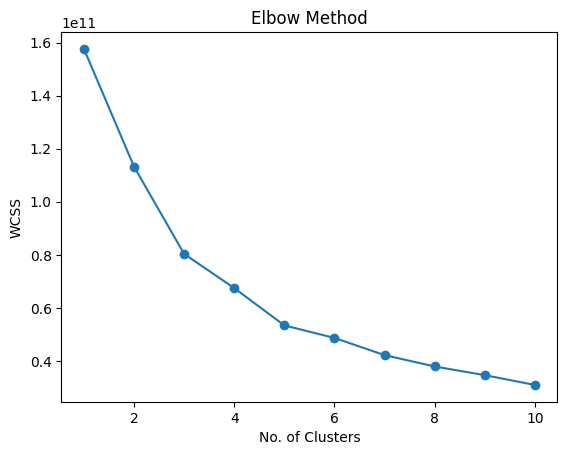

In [15]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

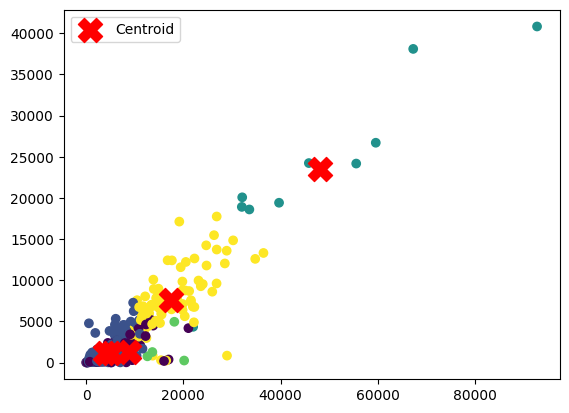

In [17]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
kmeans.fit(x)
y_means=kmeans.predict(x)
df['clusters']=kmeans.labels_
plt.scatter(x['Grocery'],x['Detergents_Paper'],c=df['clusters'],cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,2],kmeans.cluster_centers_[:,4],s=300,c='red',label='Centroid',marker='X')
plt.legend()
plt.show()

In [20]:
c=x.copy()
c['clusters']=kmeans.labels_
print(c.groupby('clusters').mean())

                 Fresh          Milk       Grocery        Frozen  \
clusters                                                           
0         23710.849057   3882.056604   5169.311321   3772.443396   
1          6485.075556   3148.573333   3798.955556   2655.751111   
2         18192.400000  35361.600000  48052.200000   3308.400000   
3         56453.307692  10026.230769   8739.000000  15518.076923   
4          4556.069767  11005.500000  17461.872093   1388.465116   

          Detergents_Paper   Delicassen  
clusters                                 
0              1118.264151  1693.103774  
1              1099.946667   986.546667  
2             23534.900000  4461.100000  
3              1258.230769  7170.538462  
4              7559.616279  1531.081395  
